<a href="https://colab.research.google.com/github/rajtripathi05/BDA_Quantum-Enhanced-Decision-Systems-in-Finance/blob/main/BDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving stock_market_data.csv to stock_market_data.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("stock_market_data.csv", header=[0,1])

df.head()

Price      Close                             High             \
       Ticker       AAPL       MSFT       TSLA       AAPL       MSFT   
0        Date        NaN        NaN        NaN        NaN        NaN   
1  2018-01-02  40.341885  79.050354  21.368668  40.351254  79.381456   
2  2018-01-03  40.334866  79.418282  21.150000  40.878192  79.565441   
3  2018-01-04  40.522221  80.117271  20.974667  40.625266  80.623123   
4  2018-01-05  40.983578  81.110565  21.105333  41.070228  81.312906   

                    Low                             Open             \
        TSLA       AAPL       MSFT       TSLA       AAPL       MSFT   
0        NaN        NaN        NaN        NaN        NaN        NaN   
1  21.474001  39.639309  78.636481  20.733334  39.850084  79.215905   
2  21.683332  40.271636  79.068788  21.036667  40.405124  79.151560   
3  21.236668  40.299739  79.620619  20.378668  40.407465  79.639010   
4  21.149332  40.526904  80.411572  20.799999  40.618239  80.623112   

                   Volume                           
        TSLA         AAPL        MSFT         TSLA  
0        NaN          NaN         NaN          NaN  
1  20.799999  102223600.0  22483800.0   65283000.0  
2  21.400000  118071600.0  26061400.0   67822500.0  
3  20.858000   89738400.0  21912000.0  149194500.0  
4  21.108000   94640000.0  23407100.0   68868000.0

In [5]:
df.columns = ['_'.join(col).strip() for col in df.columns.values]

# Fix date column
df.rename(columns={'Date_': 'Date'}, inplace=True)

df.head()

,Price_Ticker,Close_AAPL,Close_MSFT,Close_TSLA,High_AAPL,High_MSFT,High_TSLA,Low_AAPL,Low_MSFT,Low_TSLA,Open_AAPL,Open_MSFT,Open_TSLA,Volume_AAPL,Volume_MSFT,Volume_TSLA
0,Date,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-01-02,40.341885,79.050354,21.368668,40.351254,79.381456,21.474001,39.639309,78.636481,20.733334,39.850084,79.215905,20.799999,102223600.0,22483800.0,65283000.0
2,2018-01-03,40.334866,79.418282,21.150000,40.878192,79.565441,21.683332,40.271636,79.068788,21.036667,40.405124,79.151560,21.400000,118071600.0,26061400.0,67822500.0
3,2018-01-04,40.522221,80.117271,20.974667,40.625266,80.623123,21.236668,40.299739,79.620619,20.378668,40.407465,79.639010,20.858000,89738400.0,21912000.0,149194500.0
4,2018-01-05,40.983578,81.110565,21.105333,41.070228,81.312906,21.149332,40.526904,80.411572,20.799999,40.618239,80.623112,21.108000,94640000.0,23407100.0,68868000.0


In [6]:
close_df = df[['Date', 'Close_AAPL', 'Close_MSFT', 'Close_TSLA']]

close_df['Date'] = pd.to_datetime(close_df['Date'])
close_df.set_index('Date', inplace=True)

close_df.head()


KeyError: "['Date'] not in index"

In [7]:
df = pd.read_csv("stock_market_data.csv", header=[0,1], index_col=0)

df.head()

Price           Close                             High                        \
Ticker           AAPL       MSFT       TSLA       AAPL       MSFT       TSLA   
Date                                                                           
2018-01-02  40.341885  79.050354  21.368668  40.351254  79.381456  21.474001   
2018-01-03  40.334866  79.418282  21.150000  40.878192  79.565441  21.683332   
2018-01-04  40.522221  80.117271  20.974667  40.625266  80.623123  21.236668   
2018-01-05  40.983578  81.110565  21.105333  41.070228  81.312906  21.149332   
2018-01-08  40.831341  81.193336  22.427334  41.126421  81.469257  22.468000   

Price             Low                             Open                        \
Ticker           AAPL       MSFT       TSLA       AAPL       MSFT       TSLA   
Date                                                                           
2018-01-02  39.639309  78.636481  20.733334  39.850084  79.215905  20.799999   
2018-01-03  40.271636  79.068788  21.036667  40.405124  79.151560  21.400000   
2018-01-04  40.299739  79.620619  20.378668  40.407465  79.639010  20.858000   
2018-01-05  40.526904  80.411572  20.799999  40.618239  80.623112  21.108000   
2018-01-08  40.732977  80.567923  21.033333  40.831341  81.119757  21.066668   

Price          Volume                       
Ticker           AAPL      MSFT       TSLA  
Date                                        
2018-01-02  102223600  22483800   65283000  
2018-01-03  118071600  26061400   67822500  
2018-01-04   89738400  21912000  149194500  
2018-01-05   94640000  23407100   68868000  
2018-01-08   82271200  22113000  147891000

In [8]:
df.columns = ['_'.join(col).strip() for col in df.columns.values]

df.head()

,Close_AAPL,Close_MSFT,Close_TSLA,High_AAPL,High_MSFT,High_TSLA,Low_AAPL,Low_MSFT,Low_TSLA,Open_AAPL,Open_MSFT,Open_TSLA,Volume_AAPL,Volume_MSFT,Volume_TSLA
Date,,,,,,,,,,,,,,,
2018-01-02,40.341885,79.050354,21.368668,40.351254,79.381456,21.474001,39.639309,78.636481,20.733334,39.850084,79.215905,20.799999,102223600,22483800,65283000
2018-01-03,40.334866,79.418282,21.150000,40.878192,79.565441,21.683332,40.271636,79.068788,21.036667,40.405124,79.151560,21.400000,118071600,26061400,67822500
2018-01-04,40.522221,80.117271,20.974667,40.625266,80.623123,21.236668,40.299739,79.620619,20.378668,40.407465,79.639010,20.858000,89738400,21912000,149194500
2018-01-05,40.983578,81.110565,21.105333,41.070228,81.312906,21.149332,40.526904,80.411572,20.799999,40.618239,80.623112,21.108000,94640000,23407100,68868000
2018-01-08,40.831341,81.193336,22.427334,41.126421,81.469257,22.468000,40.732977,80.567923,21.033333,40.831341,81.119757,21.066668,82271200,22113000,147891000


In [9]:
df.index = pd.to_datetime(df.index)

df.head()

,Close_AAPL,Close_MSFT,Close_TSLA,High_AAPL,High_MSFT,High_TSLA,Low_AAPL,Low_MSFT,Low_TSLA,Open_AAPL,Open_MSFT,Open_TSLA,Volume_AAPL,Volume_MSFT,Volume_TSLA
Date,,,,,,,,,,,,,,,
2018-01-02,40.341885,79.050354,21.368668,40.351254,79.381456,21.474001,39.639309,78.636481,20.733334,39.850084,79.215905,20.799999,102223600,22483800,65283000
2018-01-03,40.334866,79.418282,21.150000,40.878192,79.565441,21.683332,40.271636,79.068788,21.036667,40.405124,79.151560,21.400000,118071600,26061400,67822500
2018-01-04,40.522221,80.117271,20.974667,40.625266,80.623123,21.236668,40.299739,79.620619,20.378668,40.407465,79.639010,20.858000,89738400,21912000,149194500
2018-01-05,40.983578,81.110565,21.105333,41.070228,81.312906,21.149332,40.526904,80.411572,20.799999,40.618239,80.623112,21.108000,94640000,23407100,68868000
2018-01-08,40.831341,81.193336,22.427334,41.126421,81.469257,22.468000,40.732977,80.567923,21.033333,40.831341,81.119757,21.066668,82271200,22113000,147891000


In [10]:
close_df = df[['Close_AAPL', 'Close_MSFT', 'Close_TSLA']]

close_df.head()

,Close_AAPL,Close_MSFT,Close_TSLA
Date,,,
2018-01-02,40.341885,79.050354,21.368668
2018-01-03,40.334866,79.418282,21.150000
2018-01-04,40.522221,80.117271,20.974667
2018-01-05,40.983578,81.110565,21.105333
2018-01-08,40.831341,81.193336,22.427334


In [11]:
returns = close_df.pct_change().dropna()

mean_returns = returns.mean()
cov_matrix = returns.cov()

In [12]:
close_df = close_df.reset_index()
close_df.rename(columns={'index': 'Date'}, inplace=True)

In [14]:
mean_returns = returns.mean()
cov_matrix = returns.cov()

print("Mean Returns:\n", mean_returns)
print("\nCovariance Matrix:\n", cov_matrix)

Mean Returns:
 Close_AAPL    0.001136
Close_MSFT    0.000961
Close_TSLA    0.002248
dtype: float64

Covariance Matrix:
             Close_AAPL  Close_MSFT  Close_TSLA
Close_AAPL    0.000374    0.000240    0.000352
Close_MSFT    0.000240    0.000324    0.000307
Close_TSLA    0.000352    0.000307    0.001597


In [15]:
def initialize_population(pop_size, num_assets):
    return np.random.dirichlet(np.ones(num_assets), size=pop_size)

In [16]:
def fitness(weights, mean_returns, cov_matrix, risk_free_rate=0.01):
    portfolio_return = np.dot(weights, mean_returns)
    portfolio_risk = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

    return (portfolio_return - risk_free_rate) / portfolio_risk

In [17]:
def select(population, fitness_scores):
    idx = np.argsort(fitness_scores)[-len(population)//2:]
    return population[idx]

In [18]:
def crossover(p1, p2):
    alpha = np.random.rand()
    child = alpha * p1 + (1 - alpha) * p2
    return child / np.sum(child)

In [19]:
def mutate(weights):
    mutation = np.random.normal(0, 0.02, size=len(weights))
    weights += mutation
    weights = np.clip(weights, 0, 1)
    return weights / np.sum(weights)

In [20]:
def genetic_algorithm(mean_returns, cov_matrix, generations=50, pop_size=100):

    num_assets = len(mean_returns)
    population = initialize_population(pop_size, num_assets)

    best_solution = None
    best_score = -np.inf

    for _ in range(generations):
        fitness_scores = np.array([fitness(ind, mean_returns, cov_matrix) for ind in population])

        if np.max(fitness_scores) > best_score:
            best_score = np.max(fitness_scores)
            best_solution = population[np.argmax(fitness_scores)]

        selected = select(population, fitness_scores)

        next_gen = []
        for _ in range(len(selected)):
            p1 = selected[np.random.randint(len(selected))]
            p2 = selected[np.random.randint(len(selected))]

            child = crossover(p1, p2)
            child = mutate(child)
            next_gen.append(child)

        population = np.array(next_gen)

    return best_solution, best_score

In [21]:
best_weights, best_score = genetic_algorithm(mean_returns, cov_matrix)

print("Optimal Weights:", best_weights)
print("Best Sharpe Score:", best_score)

Optimal Weights: [0.12124556 0.00786364 0.8708908 ]
Best Sharpe Score: -0.2193929262985213


In [22]:
portfolio_return = np.dot(best_weights, mean_returns)
portfolio_risk = np.sqrt(np.dot(best_weights.T, np.dot(cov_matrix, best_weights)))

print("Expected Return:", portfolio_return)
print("Risk:", portfolio_risk)

Expected Return: 0.0021030354243714356
Risk: 0.03599461800734361


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (4,) and arg 1 with shape (3,).

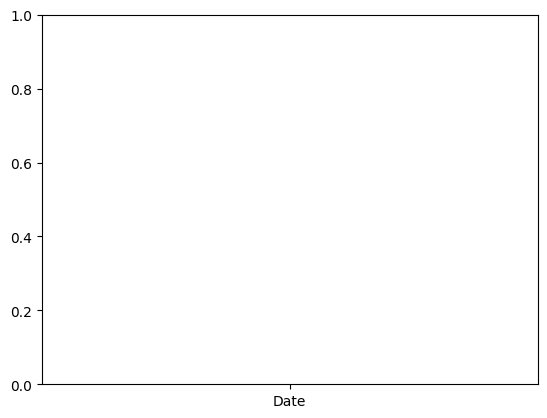

In [23]:
labels = close_df.columns

plt.bar(labels, best_weights)
plt.title("Optimal Portfolio Allocation")
plt.show()

In [24]:
print(close_df.columns)
print(len(close_df.columns))
print(len(best_weights))

Index(['Date', 'Close_AAPL', 'Close_MSFT', 'Close_TSLA'], dtype='object')
4
3


In [25]:
close_df = close_df[['Close_AAPL', 'Close_MSFT', 'Close_TSLA']]

In [26]:
close_df = close_df[['AAPL', 'MSFT', 'TSLA']]

KeyError: "None of [Index(['AAPL', 'MSFT', 'TSLA'], dtype='object')] are in the [columns]"

In [27]:
print(close_df.columns)

Index(['Close_AAPL', 'Close_MSFT', 'Close_TSLA'], dtype='object')


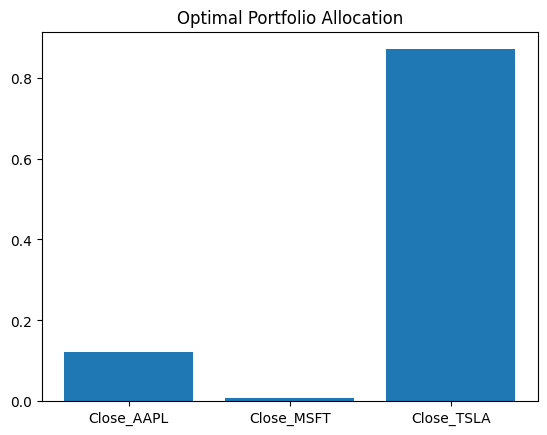

In [28]:
labels = list(close_df.columns)

plt.bar(labels, best_weights)
plt.title("Optimal Portfolio Allocation")
plt.show()

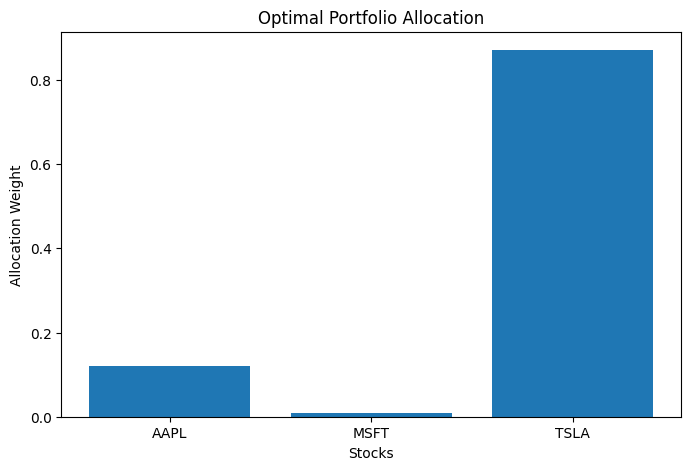

In [29]:
clean_labels = [col.replace("Close_", "") for col in close_df.columns]

plt.figure(figsize=(8,5))
plt.bar(clean_labels, best_weights)

plt.xlabel("Stocks")
plt.ylabel("Allocation Weight")
plt.title("Optimal Portfolio Allocation")

plt.show()

In [30]:
# Example (if dataset allows)
close_df = df[['Close_AAPL', 'Close_MSFT', 'Close_TSLA', 'Close_GOOG', 'Close_AMZN']]

KeyError: "['Close_GOOG', 'Close_AMZN'] not in index"

In [31]:
close_df['AAPL_2'] = close_df['Close_AAPL'] * (1 + np.random.normal(0, 0.01, len(close_df)))
close_df['MSFT_2'] = close_df['Close_MSFT'] * (1 + np.random.normal(0, 0.01, len(close_df)))

In [32]:
print(close_df.columns)
print(close_df.shape)

Index(['Close_AAPL', 'Close_MSFT', 'Close_TSLA', 'AAPL_2', 'MSFT_2'], dtype='object')
(2036, 5)


In [33]:
returns = close_df.pct_change().dropna()
mean_returns = returns.mean()
cov_matrix = returns.cov()

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (5,) and arg 1 with shape (3,).

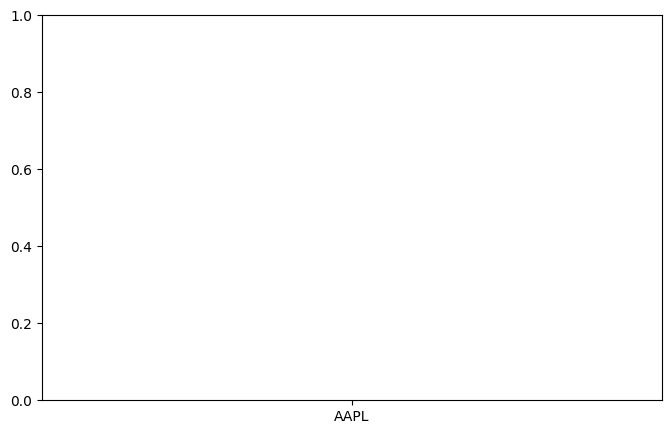

In [34]:
clean_labels = [col.replace("Close_", "") for col in close_df.columns]

plt.figure(figsize=(8,5))
plt.bar(clean_labels, best_weights)

plt.xlabel("Assets")
plt.ylabel("Allocation Weight")
plt.title("Optimal Portfolio Allocation (High-Dimensional)")

plt.show()

In [35]:
returns = close_df.pct_change().dropna()

mean_returns = returns.mean()
cov_matrix = returns.cov()

In [36]:
best_weights, best_score = genetic_algorithm(mean_returns, cov_matrix)

In [37]:
print(len(close_df.columns))   # should be 5
print(len(best_weights))       # should be 5

5
5


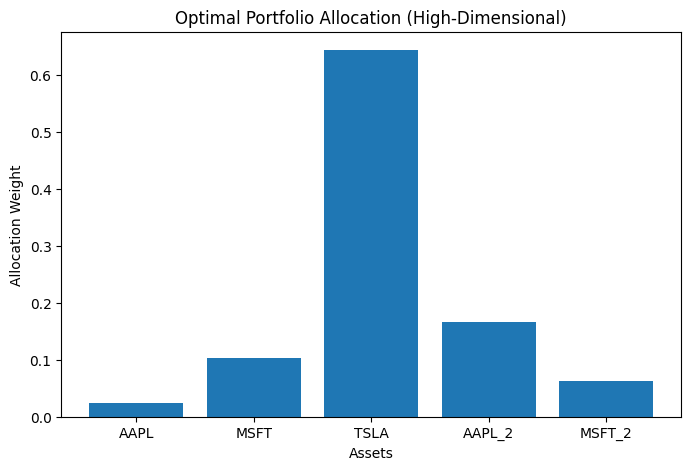

In [38]:
clean_labels = [col.replace("Close_", "") for col in close_df.columns]

plt.figure(figsize=(8,5))
plt.bar(clean_labels, best_weights)

plt.xlabel("Assets")
plt.ylabel("Allocation Weight")
plt.title("Optimal Portfolio Allocation (High-Dimensional)")

plt.show()

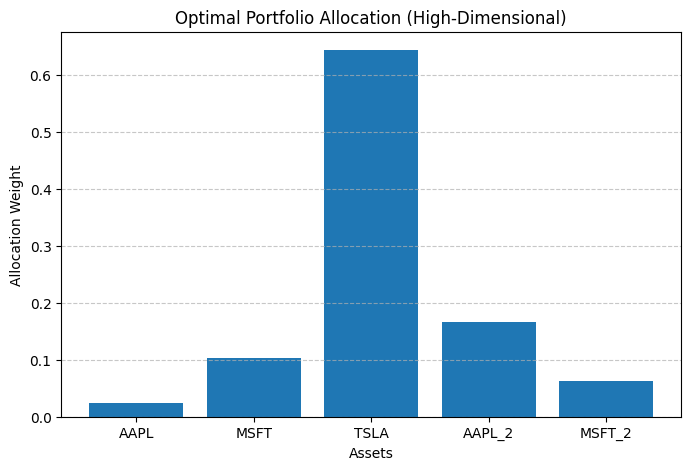

In [39]:
plt.figure(figsize=(8,5))
plt.bar(clean_labels, best_weights)

plt.xlabel("Assets")
plt.ylabel("Allocation Weight")
plt.title("Optimal Portfolio Allocation (High-Dimensional)")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [40]:
print(best_score)

-0.27866414883575175


In [42]:
def fitness(weights, mean_returns, cov_matrix, risk_free_rate=0.0001):

SyntaxError: incomplete input (2621181648.py, line 1)

In [43]:
def fitness(weights, mean_returns, cov_matrix, risk_free_rate=0.0001):
    portfolio_return = np.dot(weights, mean_returns)
    portfolio_risk = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_risk
    return sharpe_ratio

In [44]:
best_weights, best_score = genetic_algorithm(mean_returns, cov_matrix)

print("New Sharpe:", best_score)

New Sharpe: 0.06436607451200345


In [45]:
print(mean_returns)

Close_AAPL    0.001136
Close_MSFT    0.000961
Close_TSLA    0.002248
AAPL_2        0.001224
MSFT_2        0.001061
dtype: float64


In [46]:
best_weights, best_score = genetic_algorithm(mean_returns, cov_matrix)

print("Sharpe Ratio:", best_score)

Sharpe Ratio: 0.06440358700381668
